## SAMARBEID:

## Jobbet sammen med Marie Océane Pilskog, Muhammad Mohsin Mumtaz og Simon Berg

# Exercises week 38

**FYS-STK3155/4155, fall 2026 — deadline Friday September 18 at midnight.**

## Adaptive learning rates and stochastic gradient descent

The aim this week is that you extend last week's gradient descent code with
the adaptive methods AdaGrad, RMSProp and Adam, that you understand what each
of them does to the step and why their learning rate is not the learning rate
of plain gradient descent, and that you replace the full gradient by a
minibatch gradient with epochs and a learning-rate schedule. Everything here is
reused directly in parts f) and h) of Project 1. The code developed in the
Tuesday session (`week38tuesday.ipynb`, Cases 1 and 2) is meant to be reused,
and the Monday notebook (`week38.ipynb`) contains worked examples of every
piece.

After completing these exercises you will have

* derived the bias correction of Adam and the first step of the adaptive
  methods, and shown why they are insensitive to the scale of a feature;
* your own implementation of AdaGrad, RMSProp and Adam in the same
  three-function structure as last week's gradient descent, checked against
  the closed-form solutions of OLS and Ridge;
* scanned the learning rate for each method and related the windows you find
  to $2/\lambda_{\max}$ (Section 4.5) and to what $\gamma$ means for an
  adaptive method (Sections 4.8–4.12);
* a stochastic gradient descent loop with minibatches, epochs and the
  schedule of Eq. (4.40), and studied the batch size and the schedule
  (Section 4.7);
* applied all of it to the Runge function at degree 10, the problem nothing
  converged on last week.

Reading: Chapter 4, Sections 4.7–4.13 of the book; Goodfellow et al.,
Sections 8.1–8.5.

## The data

We keep last week's function,

$$
f(x) = 2 - x + 5x^2, \qquad x \in [-2, 2],
$$

with $n = 100$ points and Gaussian noise of standard deviation $0.5$, fitted
with polynomial features of degree 2 (an easy problem, $\kappa \approx 1.3$)
and degree 5 (a hard one, $\kappa \approx 520$). As last week, standardise the
columns of the design matrix, centre $\boldsymbol{y}$ and use no intercept
column; the closed-form OLS and Ridge solutions are your reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

BLUE, RED, YELLOW, GREY = "#004488", "#BB5566", "#DDAA33", "#777777"
GREEN = "#228833"
np.set_printoptions(precision=4, suppress=True)

In [2]:
def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered


def runge_data(n=100, degree=2, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()


def closed_form(X, y, lam):
    """Eq. (3.44) with the 1/n convention of Eq. (3.95): (X^T X + n lambda I)^-1 X^T y."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)


def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16): (1/n)||X theta - y||^2 + lambda theta^T theta."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta


def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    # print(n)
    return (2 / n) * X.T @ (X @ theta - y) + 2 * lam * theta


def hessian_eigs(X, lam):
    """Eigenvalues of the Hessian (2/n) X^T X + 2 lambda I, Eqs. (4.14) and (4.17)."""
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))


## Exercise 1: what the adaptive methods do to the step (analytical)

The three adaptive methods replace the single learning rate $\gamma$ by a
per-coordinate step $\gamma/\sqrt{v_j}$, where $v_j$ estimates the second
moment of the gradient in coordinate $j$ (Section 4.8).

### 1a)

Unroll the RMSProp recursion of Eq. (4.47),
$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$ with
$\boldsymbol{v}_0 = \boldsymbol{0}$, to obtain Eq. (4.49),
$\boldsymbol{v}_t = (1-\rho)\sum_{j=1}^{t}\rho^{\,t-j}\boldsymbol{g}_j^2$, and show
that the weights sum to $1 - \rho^t$. After how many steps has a gradient's
weight fallen below $1/e$ of its initial weight, for $\rho = 0.9$ and
$\rho = 0.99$? Compare with AdaGrad's sum, Eq. (4.42), whose weights are all
one.

### 1b)

Now Adam. Assume the gradient is stationary with $\mathbb{E}[g^2]$ constant.
Take the expectation of the unrolled second moment of Eq. (4.52) and derive
Eq. (4.53), $\mathbb{E}[v_t] = (1-\beta_2^{\,t})\,\mathbb{E}[g^2]$. Do the same
for the first moment with $\beta_1$. Explain why dividing by $1-\beta_i^t$,
Eq. (4.54), removes the bias exactly, and evaluate the correction factors at
$t = 1$, $t = 10$ and $t = 1000$ for the default $\beta_1 = 0.9$,
$\beta_2 = 0.999$.

### 1c)

Show that the first step of Adam, Eq. (4.55) at $t = 1$, is
$\Delta\theta_j = -\gamma\,\mathrm{sign}(g_{1,j})$ (up to $\epsilon$),
independent of the size of the gradient, and that the same holds for AdaGrad.
What is the first step of RMSProp, which has no bias correction, with
$\rho = 0.99$? What does this tell you about the meaning of $\gamma$ for these
methods, compared with plain gradient descent? Without bias correction, by
what factor would Adam's first step be too long?

### 1d)

Multiply one feature (one column of $\boldsymbol{X}$) by a constant $c$. Show
that the corresponding component of the gradient of the OLS cost scales by
$c$ and that the AdaGrad/RMSProp/Adam step in that coordinate is unchanged,
whereas the plain gradient descent step scales by $c$ (and the stability bound
$2/\lambda_{\max}$ moves). Why does this *not* mean that standardising the
data is unnecessary for the adaptive methods? (Hint: the Tuesday session's
rotated bowl.)

## Exercise 2: implementing AdaGrad, RMSProp and Adam

Extend last week's code with one step function that holds all five
optimisers. The template below has the update rules to fill in; keep the
gradient as an argument so that the analytical gradient and `jax.grad` are
interchangeable, as in part e) of Project 1.

In [3]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-6):
    """One update of theta from the gradient g at step t (t = 1, 2, ...), Eqs. (4.10), (4.28),
    (4.42)-(4.45), (4.47)-(4.48) and (4.51)-(4.55).  state carries the running quantities."""
    if method == "plain":
        return theta - gamma * g, state
    if method == "momentum":
        v = beta * state.get("v", 0.0) + gamma * g               # Eq. (4.28)
        state["v"] = v
        return theta - v, state
    if method == "adagrad":
        r = state.get("r", 0.0) + g * g                           # Eq. (4.42)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.45)
    if method == "rmsprop":
        r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g       # Eq. (4.47)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.48)
    if method == "adam":
        m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g       # Eq. (4.51)
        r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g   # Eq. (4.52)
        state["m"], state["r"] = m, r
        m_hat = m / (1.0 - beta1**t)                              # Eq. (4.54)
        r_hat = r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state   # Eq. (4.55)
    raise ValueError(f"unknown method {method}")


def optimise(grad, theta0, method, gamma, num_iters = 10000, tol = 1e-6, **kw):
    """Run one optimiser from theta0 with the full gradient; returns all iterates."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            # print("Final iteration", t)
            # print("Final theta", theta)
            break
    return history

### 2a)

Run all five methods on the degree-2 data for OLS and for Ridge with
$\lambda = 0.01$ (remember the $n\lambda\boldsymbol{I}$ of the closed form).
Use $\gamma = 0.5$ for plain gradient descent and momentum and try
$\gamma \in \{0.01, 0.1\}$ for the adaptive methods. Do all of them converge to
the closed-form solution? Plot the distance
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method.

In [4]:
lam = 0.01

def ols(X, y,lam=0.0):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ ((U.T @ y) / s)

def ridge(X,y,lam):
    return ols(X,y) * (1/(1+lam))
# OLS_method = ridge(X, y, 0, 2)
# ridge_method = ridge(X, y, lam, 2)

In [5]:
def run_method(func, gamma_grid, method,lam):
    X2, y2 = exercise_data(degree=2)
    theta2 = func(X2, y2,lam)
    grad2 = lambda th: gradient(th, X2, y2)
    gammas = gamma_grid
    np.seterr(over="ignore", invalid="ignore")   # diverging runs overflow; that is the answer, not an error
    # print("gamma grid:", np.round(gammas, 4))
    # for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):

  
    path = optimise(grad2, np.zeros(2), method, gammas)
    
    # path.append(g)

    # scan[method] = its
    # ok = [(gammas[i], its[i]) for i in range(len(its)) if its[i] is not None]
    # best = min(ok, key=lambda t: t[1]) if ok else None
    # print(f"{method:8s}: usable gamma from {ok[0][0]:.4f} to {ok[-1][0]:.4f}" if ok else f"{method:8s}: never reaches 1e-6",
    #     f"; best {best[1]} iterations at gamma = {best[0]:.3f}" if best else "")

    return theta2, path

OLS
Theta values from closed form OLS [-1.0774  5.8547]
Theta values for OLS plain [-1.0774  5.8547]
Theta values for OLS momentum [-1.0774  5.8547]

Ridge:
Theta values from closed form Ridge [-1.0596  5.7947]
The theta ridge value for adagrad [-0.9794  5.3225]
The theta ridge value for rmsprop [-0.9794  5.3225]
The theta ridge value for adam [-0.9794  5.3225]


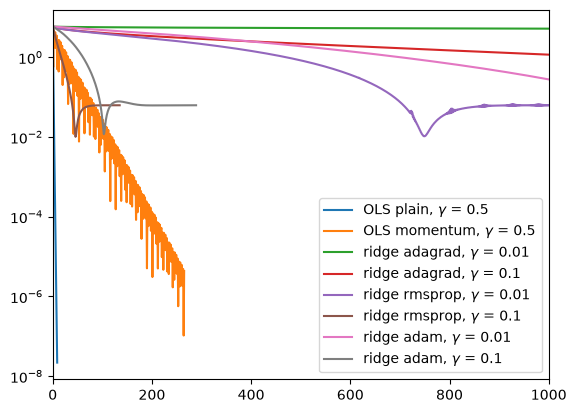

In [6]:
X, y = exercise_data(degree=2)

theta_closed_form_OLS = closed_form(X, y, lam = 0.0)
theta_closed_form_ridge = closed_form(X, y, lam = 0.01)

print("OLS")
print("Theta values from closed form OLS", theta_closed_form_OLS)


theta_ols_plain, path_ols_plain_0_5 = run_method(ols, [0.5], "plain",0.0)
theta_ols_momentum, path_ols_momentum_0_5 = run_method(ols, [0.5], "momentum",0.0)

print("Theta values for OLS plain", theta_ols_plain)
print("Theta values for OLS momentum", theta_ols_momentum)


difference_plain_0_5 = []
difference_momentum_0_5 = []


for each in path_ols_plain_0_5:
    diff = each - theta_closed_form_OLS
    # difference_plain.append(diff)
    difference_plain_0_5.append(np.abs(diff[0]+diff[1]))

for each in path_ols_momentum_0_5:
    diff = each - theta_closed_form_OLS
    # difference_momentum.append(diff)
    difference_momentum_0_5.append(np.abs(diff[0]+diff[1]))


plt.figure()
plt.plot(difference_plain_0_5, label = r"OLS plain, $\gamma$ = 0.5")
plt.plot(difference_momentum_0_5, label = r"OLS momentum, $\gamma$ = 0.5")
plt.yscale("log")

d = {}
methods = ("adagrad", "rmsprop", "adam")

print("\nRidge:")
print("Theta values from closed form Ridge", theta_closed_form_ridge)

for each in methods:
    theta_ridge, path_ridge_0_01= run_method(ridge, [0.01], each,0.01)
    theta_ridge, path_ridge_0_1= run_method(ridge, [0.1], each,0.1)

    print(f"The theta ridge value for {each}", theta_ridge) 
    # print(f"path_ridge_{each}")
    diff_array_0_01 = path_ridge_0_01-theta_closed_form_ridge
    diff_array_0_1 = path_ridge_0_1-theta_closed_form_ridge

    difference_0_01 = []
    difference_0_1 = []

    for i in diff_array_0_01:
        length = np.sqrt((i[0]**2+i[1]**2))
        # diff = np.linalg.norm(i[:,0],i[:,1])
        difference_0_01.append(length)

    for j in diff_array_0_1:
        length = np.sqrt((j[0]**2+j[1]**2))
        # diff = np.linalg.norm(i[:,0],i[:,1])
        difference_0_1.append(length)

    plt.plot(np.arange(1, len(path_ridge_0_01)+1), difference_0_01, label = rf"ridge {each}, $\gamma$ = 0.01")
    plt.plot(np.arange(1, len(path_ridge_0_1)+1), difference_0_1, label = rf"ridge {each}, $\gamma$ = 0.1")

plt.yscale("log")
plt.xlim(0,1000)
plt.legend()
plt.show()

We see that the plain gradient decent and momentum converge to the closed form solution, however, the adaptive methods do not converge towards the theta values from the colosed form solutions. 

### 2b)

Repeat for the degree-5 data ($\kappa = 520$), with $\gamma = 0.9 \cdot 2/\lambda_{\max}$
for plain descent and momentum. Report the number of iterations to reach
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ for each method,
and identify the method that does not get there at a constant $\gamma$.
Explain why, using your result from exercise 1c).

In [7]:
def exercise_data5(n=100, degree=5, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered

# def exercise_data5(n=100, degree=2, noise=0.5, seed=2026):
#     """Standardised polynomial design matrix (no intercept column) and centred targets."""
#     rng = np.random.default_rng(seed)
#     x = rng.uniform(-2.0, 2.0, n)
#     y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
#     X = np.column_stack([x**k for k in range(1, degree + 1)])
#     X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
#     return X_norm, y - y.mean()

In [8]:
def run_method5(func, gamma_grid, method, degree, X, y,lam):
    theta5 = func(X, y,lam)
    grad5 = lambda th: gradient(th, X, y)
    gammas = gamma_grid
    np.seterr(over="ignore", invalid="ignore")   # diverging runs overflow; that is the answer, not an error
    path = optimise(grad5, np.zeros(5), method, gammas)
    
    return theta5, path


In [9]:
X5, y5 = exercise_data5(degree=5)
# print("X",X5)
eigenv = hessian_eigs(X5, lam=0.01)
print(eigenv)
lambda_max = np.max(eigenv)
lambda_min = np.min(eigenv)
print(lambda_min, lambda_max)
gamma = [0.9*(2/lambda_max)]

# gamma = [0.3184]
print("Gamma is", gamma)

theta_plain, path_plain = run_method5(ridge, gamma, "plain", 5, X5, y5, 0.01)
theta_momentum, path_momentum = run_method5(ridge, gamma, "momentum", 5, X5, y5, 0.01)

#theta_plain, path_plain = run_method5(ridge, gamma, "plain", 5, X5, y5)
#theta_momentum, path_momentum = run_method5(ridge, gamma, "momentum", 5, X5, y5)




[0.0309 0.0949 0.4285 3.8731 5.6727]
0.030863455778779792 5.672736939256736
Gamma is [np.float64(0.31730715160499634)]


We see that the number of iterations needed for the plain decent is 2393 iterations. We see that the number of iterations needed for the momentum is 265.
The number of iterations needed for the convergence for th two methods depends on the number of iterations we choose to run. 



### 2c)

Check one method against a library implementation: for the degree-2 OLS
problem, run `optax.adam` (or `torch.optim.Adam`, or any other) with the same
$\gamma$, $\beta_1$, $\beta_2$ and $\epsilon$ from the same starting point, and
compare the first ten iterates with your own. They should agree to rounding.
If they do not, the usual suspects are the bias correction and the placement
of $\epsilon$ (inside or outside the square root).

In [10]:
def gradient2(theta):
    X2, y2 = exercise_data(degree=2)
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y2)
    return (2 / n) * X2.T @ (X2 @ theta - y2)

In [11]:
import optax
import jax
import jax.numpy as jnp

#using own code
X, y = exercise_data(degree=2)

theta_adam, path_adam = run_method(ols, [0.01], "adam", 0.0)
my_numbers = (path_adam[:11])
print("my numbers", my_numbers)

my_num_1 = []
my_num_2 = []
for each in my_numbers:
    my_num_1.append(each[0])
    my_num_2.append(each[1])


#using library
solver = optax.adam(0.01, 0.9, 0.999, 1e-06)
opt_state = solver.init(np.array([0.0,0.0]))


theta_optax_values = [np.array([0.0, 0.0])]

theta_optax = np.array([0.0, 0.0])
for idx in np.arange(10):
    grad = gradient2(theta_optax)
    updates, opt_state = solver.update(grad, opt_state, theta_optax)
    theta_optax = optax.apply_updates(theta_optax, updates)
    theta_optax_values.append(optax.apply_updates(theta_optax, updates))

print(theta_optax_values)

tov_1 = []
tov_2 = []
for each in theta_optax_values:
    tov_1.append(each[0])
    tov_2.append(each[1])
# print(tov_1)
# print(tov_2)

diff = np.linalg.norm(np.array(my_numbers)- np.array(theta_optax_values),axis = 1)
print(diff.tolist())



my numbers [array([0., 0.]), array([-0.01,  0.01]), array([-0.02,  0.02]), array([-0.03,  0.03]), array([-0.0399,  0.04  ]), array([-0.0499,  0.05  ]), array([-0.0598,  0.06  ]), array([-0.0697,  0.07  ]), array([-0.0795,  0.08  ]), array([-0.0893,  0.09  ]), array([-0.0991,  0.0999])]
[array([0., 0.]), Array([-0.02,  0.02], dtype=float32), Array([-0.03,  0.03], dtype=float32), Array([-0.04,  0.04], dtype=float32), Array([-0.0499,  0.05  ], dtype=float32), Array([-0.0598,  0.06  ], dtype=float32), Array([-0.0697,  0.07  ], dtype=float32), Array([-0.0796,  0.08  ], dtype=float32), Array([-0.0894,  0.09  ], dtype=float32), Array([-0.0992,  0.1   ], dtype=float32), Array([-0.1089,  0.1099], dtype=float32)]
[0.0, 0.014141938038483754, 0.014136703815289866, 0.014128190431314447, 0.014115813317546785, 0.01409984901272229, 0.014080212591427698, 0.014056613424638023, 0.014029158400828468, 0.013997747777992132, 0.013962419697592848]


## Exercise 3: the learning rate means something different to each method

### 3a)

For the degree-5 OLS problem, scan $\gamma$ over a logarithmic grid from
$10^{-3}$ to $1$ (about fifteen values) for each of the five methods, and
record the number of iterations to $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$
(or "did not converge" within 20 000 iterations). Plot iterations against
$\gamma$ for all methods in one figure, on logarithmic axes.


{'plain': [nan, nan, nan, nan, nan, nan, nan, 18682, 11406, 6964, 4251, 2595, nan, nan, nan], 'momentum': [nan, nan, nan, 13396, 8159, 4962, 3010, 1817, 1088, 642, 366, 245, 240, 247, nan], 'adagrad': [nan, nan, nan, nan, nan, nan, 8796, 3755, 2920, 3241, 3387, 3460, 3502, 3526, 3540], 'rmsprop': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], 'adam': [4217, 3002, 2036, 1327, 844, 524, 328, 284, 350, 399, 409, 401, 400, 406, 412]}


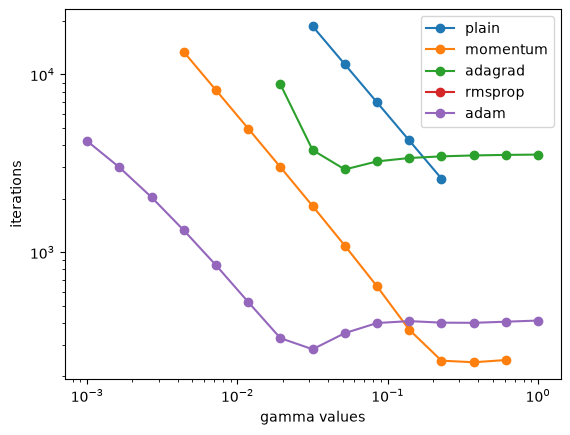

In [12]:
def gradient5(theta):
    X5, y5 = runge_data(degree = 5)
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y5)
    return (2 / n) * X5.T @ (X5 @ theta - y5)


X5_ols, y5_ols = exercise_data5()

methods = ("plain", "momentum", "adagrad", "rmsprop", "adam")


iters = {}
gam = np.logspace(-3,0,15)
for i in methods:
    iters[i] = []
    for j in gam:
        opt = optimise(gradient5, np.zeros(5), i, j, num_iters = 20000)
        # print(len(opt))
        if len(opt) >= 20000:
            iters[i].append(np.nan)
        else:
            iters[i].append(len(opt))


print(iters)

for k in methods:
    plt.plot(gam, iters[k], label = k, marker = "o")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("iterations")
plt.xlabel("gamma values")
plt.legend()


### 3b)

Discuss the figure: where does each method's window of usable $\gamma$ start
and end, and how do the edges relate to $2/\lambda_{\max}$ (plain descent),
$2(1+\beta)/\lambda_{\max}$ (momentum), and to the fact that the adaptive
methods take steps of length at most $\gamma$ per coordinate? Which method is
the least sensitive to $\gamma$, and is it also the fastest at its best
$\gamma$?

In [13]:
methods = ("plain", "momentum", "adagrad", "adam")

for each in methods: 
    print(each,": min gamma=", gam[np.nanargmin(iters[each])], ", max gamma=", gam[np.nanargmax(iters[each])])

# #values for comparison plain
# for each in gam:
#     eigs = hessian_eigs(X5_ols, each)
#     print(2/np.max(eigs))

#values for comparison momentum
beta = 0.9
for each in gam:
    eigs = hessian_eigs(X5_ols, each)
    print(2*(1+beta)/np.max(eigs))


plain : min gamma= 0.22758459260747887 , max gamma= 0.03162277660168379
momentum : min gamma= 0.3727593720314938 , max gamma= 0.004393970560760791
adagrad : min gamma= 0.0517947467923121 , max gamma= 0.019306977288832496
adam : min gamma= 0.03162277660168379 , max gamma= 0.001
0.6720029668611738
0.6718513878303861
0.6716032651588597
0.6711972622729363
0.670533332097844
0.6694487179640103
0.6676797953393886
0.6648025960563285
0.6601432431489634
0.6526512087935593
0.6407407191349599
0.6221444669516236
0.5939118703722036
0.5528223663300154
0.496554373966116


For plan: $2/\lambda_{\max}$ values are comparable with the minimum and maximum gamma values of the usable window

For momentum: $2(1+\beta)/\lambda_{\max}$ values are roughly double the value of the minimum gamma value

Adam is the least sensitive to the learning $\gamma$.

No, adam is not the fastest at its best $\gamma$. Moemntum is the fastetst at its best $\gamma$




### 3c)

Book Table 4.1 and Figure 4.7 compare the five methods at three learning
rates on a problem with $\kappa = 12$ and find that the ranking reverses
between $\gamma = 0.01$ and $\gamma = 0.5$. Reproduce this behaviour on your
degree-2 data (where $\kappa = 1.3$): which method is best at each $\gamma$, and
what is the lesson for how optimisers should be compared in Project 1?

## Exercise 4: stochastic gradient descent

Replace the full gradient by a minibatch gradient, Eq. (4.33), inside an
epoch loop. Reshuffle the data every epoch and split the shuffled indices into
minibatches of size $M$; the update of Eq. (4.34) is one call to your
`optimiser_step`, so every optimiser of exercise 2 works with minibatches
unchanged.

In [15]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None, **kw):
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else np.array(theta0, dtype=float)
    state, t, history = {}, 0, [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)            # Eq. (4.33): the minibatch gradient
            g_t = gamma if schedule is None else step_length(t, *schedule)
            theta, state = optimiser_step(method, theta, g, state, t, g_t, **kw)
        history.append(theta.copy())
    return np.array(history)


### 4a)

At a fixed point $\boldsymbol{\theta} = (0, 3)$ of the degree-2 problem,
compute the gradient on many random minibatches of size $M = 1, 5, 25$ and
compare their mean and their spread (standard deviation over batches) with the
full gradient. Verify numerically that the spread falls as $1/\sqrt{M}$, and say
in one sentence what this means for the trade-off between batch size and cost
per step.

In [16]:
X, y = exercise_data(degree=2)
n = len(y)
theta_cf = closed_form(X, y, 0)
theta = np.array([0.0, 3.0])
g_full = gradient(theta, X, y)
rng = np.random.default_rng(2026)
print("full gradient:", g_full)

M = [1,5,25]

for i in M:
    gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, i, rng)])
    print(f"M = {i:2d}: mean {np.round(gs.mean(axis=0), 3)}, spread {np.std(gs, axis=0).mean():.3f}")



print("\nWe see from the values below that the spread does indeed fall as roughly 1/sqrt(M)!")
print("M=1: ", 8.477*(1/np.sqrt(1)))
print("M=5: ",8.477*(1/np.sqrt(5)))
print("M=25: ",8.477*(1/np.sqrt(25)))



full gradient: [ 1.4783 -5.4542]
M =  1: mean [ 1.478 -5.454], spread 8.477
M =  5: mean [ 1.478 -5.454], spread 3.697
M = 25: mean [ 1.478 -5.454], spread 1.544

We see from the values below that the spread does indeed fall as roughly 1/sqrt(M)!
M=1:  8.477
M=5:  3.7910296490531437
M=25:  1.6954000000000002


The mean is pretty accurate for all chosen values for M, compared to the full gradient. For the spread, we see that it falls as $1/\sqrt{M}$.


### 4b)

Run plain SGD with $M = 5$ on the degree-2 data for 100 epochs at
$\gamma = 0.1$ and at $\gamma = 0.02$, and plot the distance to the closed-form
solution against the number of *single-point gradient evaluations* (epochs
times $n$) together with full-batch gradient descent at $\gamma = 0.5$. Which
method is ahead early, which is ahead late, and does SGD with a constant
learning rate converge at all? Relate the size of the plateau to $\gamma$.

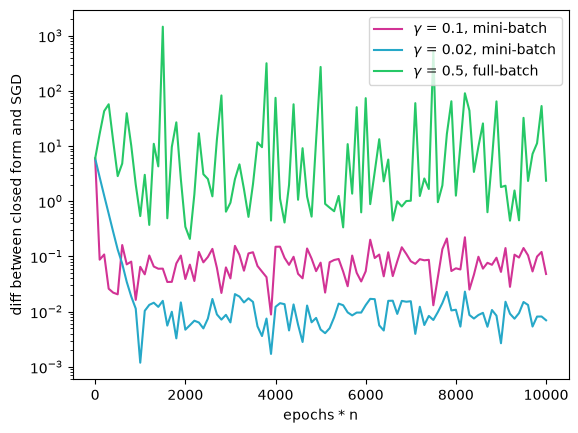

In [17]:
f_01 = sgd(X, y, method="plain", n_epochs=100, batch_size=5, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None)
f_002 = sgd(X, y, method="plain", n_epochs=100, batch_size=5, gamma=0.02, schedule=None,
        lam=0.0, seed=2026, theta0=None)

f_05 = sgd(X, y, method="plain", n_epochs=100, batch_size=1, gamma=0.5, schedule=None,
        lam=0.0, seed=2026, theta0=None)

diff_01 = theta_cf-f_01
diff_01= theta_cf-f_01

diff_002 = theta_cf-f_002
diff_002= theta_cf-f_002

diff_05 = theta_cf-f_05
diff_05= theta_cf-f_05

l_01 = np.sqrt(diff_01[:,0]**2 + diff_01[:,1]**2)
l_002 = np.sqrt(diff_002[:,0]**2 + diff_002[:,1]**2)
l_05 = np.sqrt(diff_05[:,0]**2 + diff_05[:,1]**2)
# print(diff)

plt.figure()
plt.plot(np.linspace(0,10000,101), l_01, color = "#D23395", label = fr"$\gamma$ = 0.1, mini-batch")
plt.plot(np.linspace(0,10000,101), l_002, color = "#26A8C8", label = fr"$\gamma$ = 0.02, mini-batch")
plt.plot(np.linspace(0,10000,101), l_05, color = "#26C867", label = fr"$\gamma$ = 0.5, full-batch")
# plt.ylim(0,0.3)
plt.yscale("log")
plt.xlabel("epochs * n")
plt.ylabel("diff between closed form and SGD")
plt.legend()
plt.show()



### 4c)

Now the schedule of Eq. (4.40). With $(t_0, t_1) = (1, 10)$ the initial
learning rate is $0.1$. Add this run to the plot of 4b). Then move to the
degree-5 data and run the same schedule: what happens? Find a pair $(t_0, t_1)$
with the same initial learning rate that works there, and explain your choice
in terms of the Robbins–Monro conditions $\sum_t \gamma_t = \infty$,
$\sum_t \gamma_t^2 < \infty$.

degree 2:
  t0, t1 = (1.0, 10.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0005, distance after 10 / 100 epochs 2.2e-02 / 4.7e-04
  t0, t1 = (5.0, 50.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0024, distance after 10 / 100 epochs 2.3e-03 / 2.2e-04
  t0, t1 = (20.0, 200.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0091, distance after 10 / 100 epochs 2.1e-02 / 2.3e-03


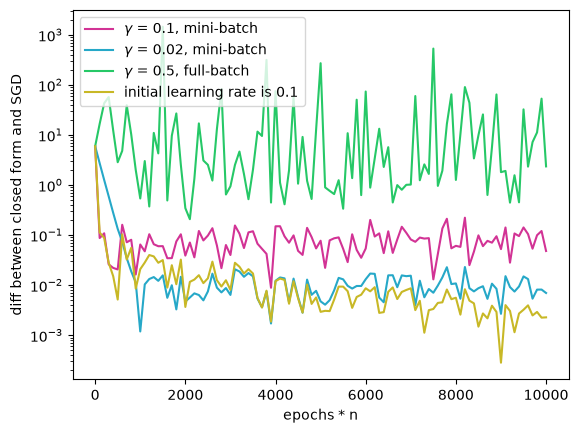

In [18]:
for degree in [2]:
    Xd, yd = exercise_data(degree=degree)
    theta_d = closed_form(Xd, yd,0)
    print(f"degree {degree}:")
    for sched in ((1.0, 10.0), (5.0, 50.0), (20.0, 200.0)):
        hist = sgd(Xd, yd, n_epochs=100, batch_size=5, schedule=sched)
        d = np.linalg.norm(hist - theta_d, axis=1)
        print(f"  t0, t1 = {sched}: gamma_0 = {sched[0] / sched[1]:.2f}, gamma after 100 epochs = {step_length(100 * len(yd) // 5, *sched):.4f}, "
              f"distance after 10 / 100 epochs {d[10]:.1e} / {d[100]:.1e}")

plt.figure()
plt.plot(np.linspace(0,10000,101), l_01, color = "#D23395", label = fr"$\gamma$ = 0.1, mini-batch")
plt.plot(np.linspace(0,10000,101), l_002, color = "#26A8C8", label = fr"$\gamma$ = 0.02, mini-batch")
plt.plot(np.linspace(0,10000,101), l_05, color = "#26C867", label = fr"$\gamma$ = 0.5, full-batch")
plt.plot(np.linspace(0,10000,101), d, color = "#C8B826", label = fr"initial learning rate is $0.1$")
# plt.ylim(0,0.3)
plt.yscale("log")
plt.xlabel("epochs * n")
plt.ylabel("diff between closed form and SGD")
plt.legend()
plt.show()

degree 5:
  t0, t1 = (1.0, 10.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0005, distance after 10 / 100 epochs 2.1e-02 / 2.3e-03
  t0, t1 = (5.0, 50.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0024, distance after 10 / 100 epochs 2.1e-02 / 2.3e-03
  t0, t1 = (20.0, 200.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0091, distance after 10 / 100 epochs 2.1e-02 / 2.3e-03


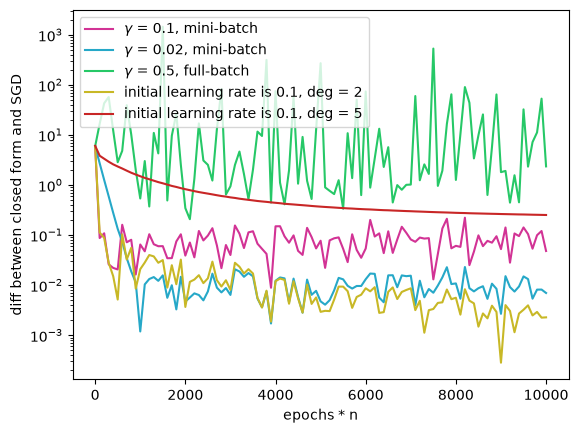

In [19]:
for degree in [5]:
    Xd, yd = exercise_data(degree=degree)
    theta_d = closed_form(Xd, yd,0)
    print(f"degree {degree}:")
    for sched in ((1.0, 10.0), (5.0, 50.0), (20.0, 200.0)):
        hist = sgd(Xd, yd, n_epochs=100, batch_size=5, schedule=sched)
        d5 = np.linalg.norm(hist - theta_d, axis=1)
        print(f"  t0, t1 = {sched}: gamma_0 = {sched[0] / sched[1]:.2f}, gamma after 100 epochs = {step_length(100 * len(yd) // 5, *sched):.4f}, "
              f"distance after 10 / 100 epochs {d[10]:.1e} / {d[100]:.1e}")

plt.figure()
plt.plot(np.linspace(0,10000,101), l_01, color = "#D23395", label = fr"$\gamma$ = 0.1, mini-batch")
plt.plot(np.linspace(0,10000,101), l_002, color = "#26A8C8", label = fr"$\gamma$ = 0.02, mini-batch")
plt.plot(np.linspace(0,10000,101), l_05, color = "#26C867", label = fr"$\gamma$ = 0.5, full-batch")
plt.plot(np.linspace(0,10000,101), d, color = "#C8B826", label = fr"initial learning rate is $0.1$, deg = 2")
plt.plot(np.linspace(0,10000,101), d5, color = "#C82626", label = fr"initial learning rate is $0.1$, deg = 5")

# plt.ylim(0,0.3)
plt.yscale("log")
plt.xlabel("epochs * n")
plt.ylabel("diff between closed form and SGD")
plt.legend()
plt.show()

COMMENTS TO EXERCISE:

The Robbins-Monro conditions basically says that in order to reach the EXACT correct point, the sum of the learning rates must diverge to infinity.  

### 4d)

Study the batch size on the degree-5 data at $\gamma = 0.1$: $M \in \{1, 5, 20, 100\}$
for 100 epochs. One of these runs diverges although $\gamma$ is below
$2/\lambda_{\max}$ of the full Hessian. Which Hessian is relevant for a single
minibatch step, and what is its largest eigenvalue for $M = 1$? (For a single
point it is $2\|\boldsymbol{x}_i\|^2$.)


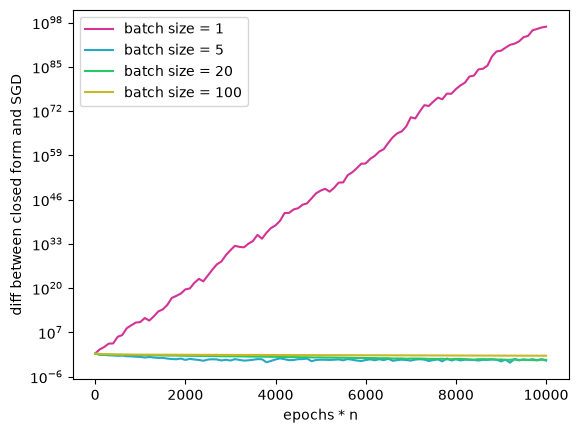

The calculated learning rate is 0.3538109099170241


In [20]:
X5, y5 = exercise_data5()
theta_cf = closed_form(X5, y5, 0)

batch_1 = sgd(X5, y5, method="plain", n_epochs=100, batch_size=1, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None)
batch_5 = sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None)
batch_20 = sgd(X5, y5, method="plain", n_epochs=100, batch_size=20, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None)
batch_100 = sgd(X5, y5, method="plain", n_epochs=100, batch_size=100, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None)


diff_1 = theta_cf-batch_1
diff_5 = theta_cf-batch_5
diff_20 = theta_cf-batch_20
diff_100 = theta_cf-batch_100



l_1 = np.sqrt(diff_1[:,0]**2 + diff_1[:,1]**2)
l_5 = np.sqrt(diff_5[:,0]**2 + diff_5[:,1]**2)
l_20 = np.sqrt(diff_20[:,0]**2 + diff_20[:,1]**2)
l_100 = np.sqrt(diff_100[:,0]**2 + diff_100[:,1]**2)

plt.figure()
plt.plot(np.linspace(0,10000,101), l_1, color = "#D23395", label = fr"batch size = 1")
plt.plot(np.linspace(0,10000,101), l_5, color = "#26A8C8", label = fr"batch size = 5")
plt.plot(np.linspace(0,10000,101), l_20, color = "#26C867", label = fr"batch size = 20")
plt.plot(np.linspace(0,10000,101), l_100, color = "#C8B826", label = fr"batch size = 100")


# plt.ylim(0,0.3)
plt.yscale("log")
plt.xlabel("epochs * n")
plt.ylabel("diff between closed form and SGD")
plt.legend()
plt.show()


H = hessian_eigs(X5, 0)
print("The calculated learning rate is", 2/np.max(H))






COMMENTS TO EXERCISE:

For a single mini-batch step (M=1), we use the standard Hessian, because it will include all the values we have in our data set.
It is clear that the run with a batch size = 1 diverges. 


### 4e)

Combine SGD with Adam on the degree-5 data ($M = 5$, $\gamma \in \{0.01, 0.05\}$,
100 epochs) and compare with plain SGD and with momentum. Which combination
comes closest to the closed-form solution, and which one fails? This is the
setting of Project 1, part h).

## Exercise 5: the Runge function at degree 10 (Project 1, parts f and h)

Last week nothing converged on the Runge function $f(x) = 1/(1+25x^2)$ on
$[-1, 1]$ ($n = 100$, noise $0.1$) with a degree-10 polynomial:
$\kappa \approx 2 \times 10^6$. Use the Tuesday session's `runge_data` (the same
standardisation as above).

### 5a)

Run momentum and Adam with the full gradient for 30 000 iterations and plot
the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. What accuracy do they reach, and does either of them
resolve the flat directions? Explain, with the rotated bowl of the Tuesday
session in mind, why a diagonal rescaling cannot fix a problem whose
ill-conditioning comes from strongly correlated columns.

This means that lambda_max =  9.973075558007407
This means that our learning rate gamma is 0.1804859483446684
The theta OLS values are [ -0.1146  -3.0908   0.4326  13.4079  -0.6377 -26.5268   0.311   24.3549
   0.0001  -8.4048]


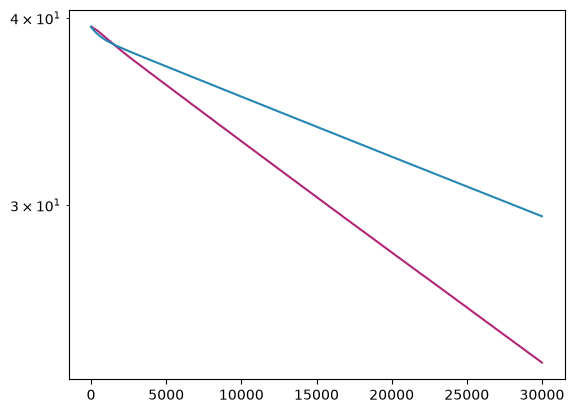

The accuracy of adam is  23.54470028388696
The accuracy of momentum is  29.484128183963325


In [22]:
def gradient3(theta):
    X3, y3 = runge_data(n = 100, degree = 10, noise=0.1, seed = 2026)
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y3)
    return (2 / n) * X3.T @ (X3 @ theta - y3)

X_runge, y_runge = runge_data(n = 100, degree = 10, noise=0.1, seed = 2026)

#check lambda_max
hessian_runge = hessian_eigs(X_runge, 0)
lambda_max = np.max(hessian_runge)
print("This means that lambda_max = ", lambda_max)

gamma = 0.9*(2/lambda_max)
print("This means that our learning rate gamma is", gamma)

adam = optimise(gradient3, np.zeros(10), "adam", gamma, num_iters = 30000, tol = 0)
momentum = optimise(gradient3, np.zeros(10), "momentum", gamma, num_iters = 30000, tol = 0)


#=====================================================================================

theta_ols = ols(X_runge, y_runge,0)
print("The theta OLS values are", (theta_ols))

diff_adam = theta_ols - adam
diff_momentum = theta_ols - momentum

l_adam = np.linalg.norm(diff_adam, axis = 1)
l_momentum = np.linalg.norm(diff_momentum, axis = 1)


plt.figure()
plt.plot(np.arange(30001), l_adam, color = "#B22577")
plt.plot(np.arange(30001), l_momentum, color = "#2588B2")
plt.yscale("log")
plt.show()

print("The accuracy of adam is ", l_adam[-1])
print("The accuracy of momentum is ", l_momentum[-1])


### 5b)

Add Ridge with $\lambda \in \{10^{-3}, 10^{-2}\}$: what are the condition
numbers now, and how many iterations do momentum and Adam need to reach an
excess cost of $10^{-8}$? Compare the Ridge coefficients with the OLS ones and
discuss whether Ridge is "cheating" — what problem has it solved, and is that
the problem you wanted solved? (Part i) of Project 1 answers the last question
with cross-validation.)

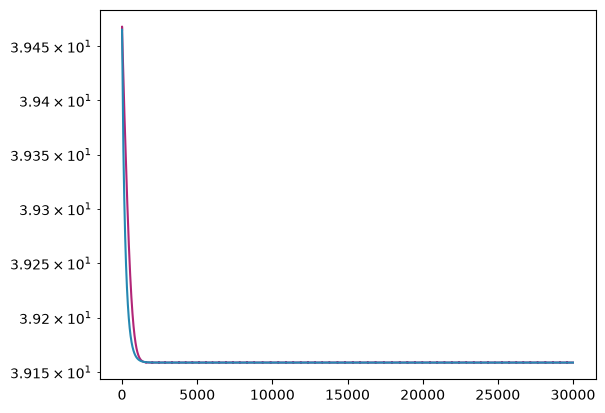

The accuracy of adam is  39.15862245918601
The accuracy of momentum is  39.15862245918624


In [24]:
def gradient4(theta):
    X4, y4= runge_data(n = 100, degree = 10, noise=0.1, seed = 2026)
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y4)
    return (2 / n) * X4.T @ (X4 @ theta - y4) + 2 * 0.001 * theta


adam_ridge = optimise(gradient4, np.zeros(10), "adam", gamma, num_iters = 30000, tol = 0)
momentum_ridge = optimise(gradient4, np.zeros(10), "momentum", gamma, num_iters = 30000, tol = 0)

diff_adam_ridge = theta_ols - adam_ridge
diff_momentum_ridge = theta_ols - momentum_ridge

l_adam_ridge = np.linalg.norm(diff_adam_ridge, axis = 1)
l_momentum_ridge = np.linalg.norm(diff_momentum_ridge, axis = 1)


plt.figure()
plt.plot(np.arange(30001), l_adam_ridge, color = "#B22577")
plt.plot(np.arange(30001), l_momentum_ridge, color = "#2588B2")
plt.yscale("log")
plt.show()

print("The accuracy of adam is ", l_adam_ridge[-1])
print("The accuracy of momentum is ", l_momentum_ridge[-1])

COMMENT TO EXERCISE:

It never reaches the tolerance, but seems to converge at a different level?? Not sure what is going on...



### 5c)

Take one Newton step from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ with the exact
Hessian $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ — or, following week 37, with
`jax.hessian` of your cost — and compare with the closed form. What did Newton
use that none of the first-order methods had, and why can we not simply do
this for a neural network?

### 5d)

Finally, minibatches: run SGD with Adam ($M = 10$, a decaying schedule of
your choice, 500 epochs) on the degree-10 problem and compare the excess cost
per gradient evaluation with the full-gradient Adam run of 5a). Give a
critical assessment, in the spirit of part h) of Project 1: what has the noise
bought, and what has it cost?

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| Adam converged for every learning rate from $10^{-3}$ to $1$ and plain gradient descent only in a narrow window. Does $\gamma$ not matter for Adam? | It matters for speed, not for stability: the adaptive step is at most $\gamma$ per coordinate (division by $\sqrt{\hat v}$), so $\gamma$ is a *length in parameter space* and cannot violate Eq. (4.20) — but the best $\gamma$ was still several times faster than the worst. |
| RMSProp at a constant $\gamma$ never reached $10^{-6}$ on a convex quadratic. Why? | Near the minimum $r \approx g^2$ and the step is $\approx \gamma\,\mathrm{sign}(g)$, a fixed length that cannot shrink: the iterate rattles at radius $\sim\gamma$. It needs a decaying $\gamma$ (Eq. 4.40), or the first moment — which is Adam. |
| AdaGrad was slower than plain gradient descent on the degree-6 Runge problem. Is it broken? | No: $\boldsymbol{r}_t$ never forgets, Eq. (4.42), so the effective learning rate decays like $1/\sqrt t$ whether or not the minimum is near. That is the wrong behaviour on a smooth convex problem and the right one for sparse features, which it was designed for. |
| Why does Adam divide its moments by $1 - \beta_i^t$? | Both averages start from zero, so $\mathbb{E}[v_t] = (1-\beta_2^t)\,\mathbb{E}[g^2]$, Eq. (4.53): at $t=1$ the raw second moment is a thousand times too small and the step would be $\sqrt{1000}/\sqrt{10}\approx 3$ times too long. Dividing by the known factor removes the bias exactly; for large $t$ the correction vanishes. |
| What does "adaptive" mean, in one sentence? | Each coordinate gets its own step $\gamma/\sqrt{v_j}$, with $v_j$ the recent mean square gradient as a proxy for the curvature $\lambda_j$: a diagonal, $\mathcal{O}(p)$ imitation of Newton's $\boldsymbol{H}^{-1/2}$ (Section 4.8). |
| Rotating the bowl by $45^\circ$ left plain gradient descent unchanged and made AdaGrad and RMSProp fail. Why? | Eq. (4.19) depends on the eigenvalues only, which a rotation preserves; the adaptive methods rescale *coordinates* and see only the diagonal of $\boldsymbol{H}$. A valley that is not axis-aligned — a correlated polynomial basis, for instance — has its curvature off the diagonal. |
| Every first-order method stalled at an excess cost of $10^{-3}$ on the degree-10 Runge problem, and one Newton step solved it. What did Newton have? | The full Hessian, off-diagonal entries included: $\kappa = 2\times10^6$ is invisible to it, Eq. (4.8). We cannot afford it for a network ($\mathcal{O}(p^3)$); every method from momentum to Adam is a cheaper approximation to it. |
| Book Table 4.1: no optimiser is best at the same $\gamma$ as any other. What does that mean for comparing methods? | A learning rate is not comparable across optimisers — plain descent multiplies the gradient by $\gamma$, the adaptive methods normalise it first. Compare methods at each one's *best* $\gamma$, found by a scan, never at one shared value. |
| Plain SGD with $M=5$ sat at a distance $5\times10^{-2}$ from the minimum for ninety epochs. Has it converged? | No, it has equilibrated: the minibatch gradient is an unbiased estimate with noise $\propto 1/\sqrt M$ (Section 2.5), and at constant $\gamma$ the iterate is a random walk in a cloud of radius $\propto\sqrt\gamma/\sqrt M$. A longer run does not help; a smaller $\gamma$, a larger $M$ or a decaying $\gamma_t$ does. |
| Full-batch gradient descent beat SGD per gradient evaluation on the degree-2 data. Is SGD overrated? | On a small benign problem the exact gradient is cheap and converges geometrically, Eq. (4.26). For $n = 10^6$ one full gradient costs $10^4$ minibatch steps: per unit of computation SGD is far ahead, and it never needs the whole data set in memory — which is why every framework is built on minibatches. |
| The schedule $(t_0,t_1)=(1,10)$ worked at degree 2 and froze at degree 5. Which condition did it break? | Robbins–Monro needs $\sum_t\gamma_t = \infty$; in a finite run $\gamma_t = t_0/(t+t_1)$ with a small $t_1$ decays so fast that the accumulated step cannot cross a $\kappa = 520$ valley. Keep $\gamma_0 = t_0/t_1$ and enlarge both, so the decay starts later. |
| SGD with $M=1$ diverged at a $\gamma$ below $2/\lambda_{\max}$ of the full Hessian. How? | A minibatch step sees the Hessian of the *minibatch* cost; for one point it is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$ with eigenvalue $2\|\boldsymbol{x}_i\|^2$, far above the average. The full-batch bound is a bound on the average, not on every step. |
| When should I stop a stochastic run? | Not on the gradient: monitor the validation cost and stop when it rises while the training cost still falls (early stopping, Section 4.7.1) — a regularisation method as much as a termination rule. |


### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 18 at midnight**. Collaboration is encouraged — list
your collaborators.